Output folder: C:\Users\Minerva\Desktop\MJ2505\MJ2505_Step1\Step1_Denmark_full_year_results\run_20261006_210103_837491
DHNx 0.0.4; oemof.solph 0.6.5
Study region: Denmark, Near Copenhagen. Coordinates are schematic local metres.
Full year: 8760 hours; 6051 exact distinct load states.
Producer assumptions:
                     technology  capacity_kW_heat  efficiency_LHV  fuel_EUR_MWh_input  variable_OM_EUR_MWh_heat  heat_cost_EUR_kWh
producer_id                                                                                                                       
0              Wood-chip boiler             400.0            0.89                30.0                       3.0            0.03671
1            Natural-gas boiler             400.0            0.93                70.0                       2.0            0.07727
Only one sequence given. Need more than one time-index to compare.
Full-year evaluation: 2000/6051 exact states.
Full-year evaluation: 4000/6051 exact states.
Full-year 

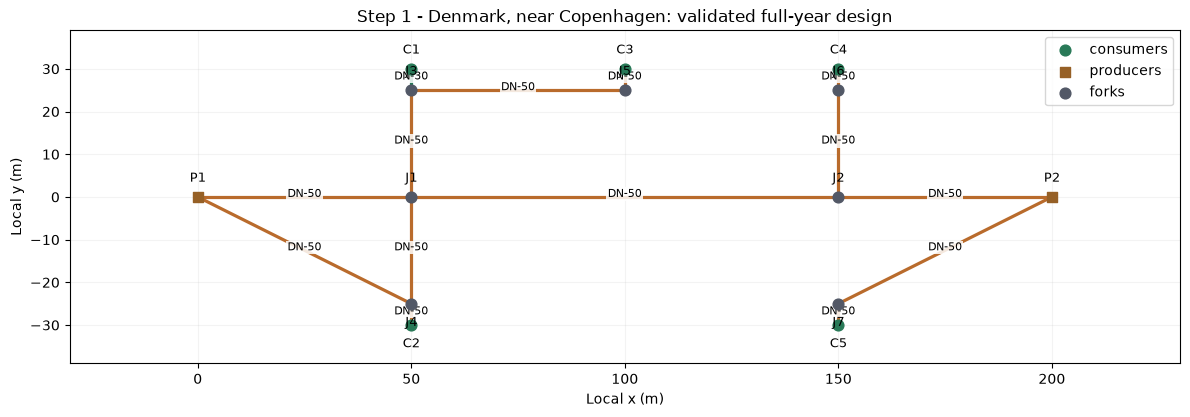

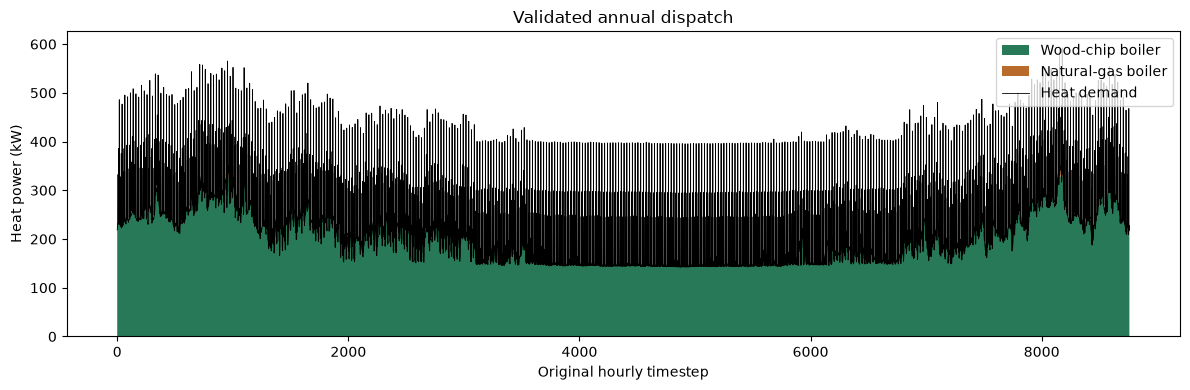


Selected pipes:
pipe_id   from_node     to_node hp_type  length_m  capacity_kW  loss_kW  output_lower_kW  output_upper_kW  initial_cost_EUR  annualised_cost_EUR  max_abs_input_kW  max_abs_output_kW  max_utilisation_percent
     15     forks-6 consumers-4   DN-50    5.0000        179.0   0.0455              0.0         178.9545         2815.0000             183.1198          168.9752           168.9297                  94.3996
     16 producers-0     forks-3   DN-50   55.9017        179.0   0.5087           -179.0         178.4913        31472.6565            2047.3415          179.0000           178.4913                 100.0000
     14     forks-5 consumers-3   DN-50    5.0000        179.0   0.0455              0.0         178.9545         2815.0000             183.1198          148.9752           148.9297                  83.2264
     17 producers-1     forks-6   DN-50   55.9017        179.0   0.5087           -179.0         178.4913        31472.6565            2047.3415          1

In [3]:
"""Step 1: exact full-year DHNx investment optimisation with Benders cuts.
Region: Denmark, near Copenhagen; positions and economic data remain scenario assumptions.
Repeated identical hours are grouped exactly. No representative-hour cost approximation is used.
"""
from pathlib import Path
from datetime import datetime
from time import perf_counter
from threading import Event, Thread
from contextlib import redirect_stdout
import argparse
import io
import json
import os
import sys
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from pyomo.environ import ConstraintList, Constraint, Var, SolverFactory, value, Objective, NonNegativeReals, minimize
from pyomo.opt import TerminationCondition
import_messages = io.StringIO()
with redirect_stdout(import_messages):
    import dhnx
    import oemof.solph as solph
    from dhnx.optimization.optimization_models import setup_optimise_investment

# 1. Settings: keep the original CSV files and use the dhnx_env kernel.
BASE = Path(r"C:\Users\Minerva\Desktop\MJ2505\MJ2505_Step1")
COUNTRY = "Denmark"
REGION = "Near Copenhagen"
TIME_LIMIT = 1800
MIP_GAP = 0.0
ABSOLUTE_GAP_EUR = 0.02
MAX_ITERATIONS = 80
DT, RATE, LIFE = 1.0, 0.05, 30
TOL = 1e-5
parser = argparse.ArgumentParser()
parser.add_argument("--base", type=Path, default=BASE)
parser.add_argument("--output", type=Path)
parser.add_argument("--time-limit", type=float, default=TIME_LIMIT)
parser.add_argument("--gap", type=float, default=MIP_GAP)
parser.add_argument("--max-iterations", type=int, default=MAX_ITERATIONS)
parser.add_argument("--seed", type=Path)
args, _ = parser.parse_known_args()
if args.time_limit <= 0 or not 0 <= args.gap < 1 or args.max_iterations < 1:
    raise ValueError("Invalid time limit, gap or iteration count.")
BASE = args.base
OUT = args.output or BASE / "Step1_Denmark_full_year_results" / datetime.now().strftime("run_%Y%m%d_%H%M%S_%f")
OUT.mkdir(parents=True, exist_ok=True)
CRF = RATE * (1 + RATE)**LIFE / ((1 + RATE)**LIFE - 1)
print(f"Output folder: {OUT}", flush=True)
(OUT / "optional_import_messages.log").write_text(import_messages.getvalue(), encoding="utf-8")

def save_json(path, data):
    path.write_text(json.dumps(data, indent=2, allow_nan=False), encoding="utf-8")

def progress(stage, elapsed=0):
    save_json(OUT / "progress.json", {"stage": stage, "elapsed_seconds": round(elapsed, 1),
        "updated_at": datetime.now().isoformat(timespec="seconds")})

class Heartbeat:
    def __init__(self, stage):
        self.stage, self.stop = stage, Event()
    def __enter__(self):
        self.start = perf_counter()
        progress(self.stage)
        def report():
            while not self.stop.wait(30):
                elapsed = perf_counter() - self.start
                progress(self.stage, elapsed)
                print(f"{self.stage}: {elapsed:.0f} s elapsed.", flush=True)
        self.thread = Thread(target=report, daemon=True)
        self.thread.start()
        return self
    def __exit__(self, kind, error, traceback):
        self.stop.set()
        self.thread.join()
        progress(self.stage + (" failed" if kind else " finished"), perf_counter() - self.start)

# Declared scenario assumptions; these are not measured prices or boiler sizes.
boilers = pd.DataFrame({"technology": ["Wood-chip boiler", "Natural-gas boiler"],
    "capacity_kW_heat": [400.0, 400.0], "efficiency_LHV": [0.89, 0.93],
    "fuel_EUR_MWh_input": [30.0, 70.0], "variable_OM_EUR_MWh_heat": [3.0, 2.0]},
    index=pd.Index(["0", "1"], name="producer_id"))
boilers["heat_cost_EUR_kWh"] = (boilers.fuel_EUR_MWh_input / boilers.efficiency_LHV
    + boilers.variable_OM_EUR_MWh_heat) / 1000
cbc_folder = Path(sys.prefix) / "Library/bin"
if (cbc_folder / "cbc.exe").is_file():
    os.environ["PATH"] = str(cbc_folder) + os.pathsep + os.environ.get("PATH", "")
if not SolverFactory("cbc").available(exception_flag=False):
    raise RuntimeError("CBC not found. Select the dhnx_env kernel or activate dhnx_env.")
print(f"DHNx {dhnx.__version__}; oemof.solph {solph.__version__}")
print(f"Study region: {COUNTRY}, {REGION}. Coordinates are schematic local metres.")

# 2. Read the checked inputs. Hourly kWh / 1 h gives average kW without scaling.
frames = {}
for group in ["consumers", "producers", "forks", "pipes"]:
    frame = pd.read_csv(BASE / f"twn_data/{group}.csv", index_col="id")
    frame.index = frame.index.map(str)
    frame.index.name = "id"
    if not frame.index.is_unique or frame.isna().any().any():
        raise ValueError(f"Duplicate IDs or missing values in {group}.csv")
    frames[group] = frame
demand = pd.read_csv(BASE / "twn_data/sequences/consumers-heat_flow.csv",
    index_col="timestep", float_precision="round_trip")
consumer_ids = [str(i) for i in range(5)]
if demand.shape != (8760, 5) or list(demand.columns) != consumer_ids:
    raise ValueError("Expected 8760 hours and consumer columns 0,...,4.")
if not np.array_equal(demand.index, np.arange(8760)):
    raise ValueError("Expected ordered timestep values 0,...,8759.")
if not np.isfinite(demand.to_numpy()).all() or (demand < 0).any().any():
    raise ValueError("Non-finite or negative heat demand.")
if set(frames["consumers"].index) != set(consumer_ids) or set(frames["producers"].index) != {"0", "1"}:
    raise ValueError("Expected five consumers and two producers.")
if not np.allclose(frames["consumers"].loc[consumer_ids, "P_heat_max"], demand.max(), atol=1e-5, rtol=0):
    raise ValueError("Consumer peaks do not match the hourly data.")
mapping = pd.read_csv(BASE / "assumptions/consumer_load_mapping.csv", dtype={"consumer_id": str})
mapping = mapping.set_index("consumer_id")
if mapping.loc[consumer_ids, "source_column"].tolist() != ["Load 2", "Load 4", "Load 10", "Load 16", "Load 22"]:
    raise ValueError("Unexpected consumer-load mapping; review before changing this check.")
catalogue = pd.read_csv(BASE / "invest_data/network/pipes.csv")
if len(catalogue) != 2 or set(catalogue.label_3) != {"DN-30", "DN-50"} or not (catalogue.nonconvex == 1).all():
    raise ValueError("Step 1 requires discrete DN-30 and DN-50 investment options.")
if not np.isfinite(catalogue.select_dtypes(include="number")).all().all():
    raise ValueError("Invalid pipe catalogue.")
if (catalogue.cap_min < 0).any() or (catalogue.cap_max < catalogue.cap_min).any():
    raise ValueError("Invalid catalogue capacity bounds.")
# Using cap_max is equivalent here: capacity has no variable capital cost or loss.
if not np.allclose(catalogue.capex_pipes, 0) or not np.allclose(catalogue.l_factor, 0):
    raise ValueError("This version requires capex_pipes=0 and l_factor=0; review before changing them.")
capital_catalogue = catalogue.copy()
catalogue["fix_costs"] *= CRF
catalogue["capex_pipes"] *= CRF
HOURS = len(demand)
loads = demand.to_numpy()
all_states = demand.drop_duplicates().reset_index(drop=True)
state_ids = demand.groupby(list(demand.columns), sort=False).ngroup().to_numpy(dtype=int)
if not np.array_equal(all_states.to_numpy()[state_ids], loads):
    raise RuntimeError("Exact repeated-state mapping failed.")
print(f"Full year: {HOURS} hours; {len(all_states)} exact distinct load states.")
print("Producer assumptions:\n" + boilers.round(5).to_string())
boilers.to_csv(OUT / "producer_assumptions.csv")
mapping.to_csv(OUT / "consumer_load_mapping.csv")
capital_catalogue.to_csv(OUT / "pipe_capital_parameters.csv", index=False)
assumptions = {"country": COUNTRY, "study_region": REGION, "hours": HOURS,
    "time_step_h": DT, "power_unit": "kW", "energy_unit": "kWh",
    "method": "DHNx investment master; exact all-hour operational LPs and Benders cuts",
    "time_aggregation": "exact duplicate vectors only; occurrence counts sum to 8760",
    "representative_hour_cost_approximation": False,
    "full_year_relative_gap_target": args.gap, "absolute_gap_tolerance_EUR": ABSOLUTE_GAP_EUR,
    "search_seconds_target": args.time_limit,
    "pipe_units_assumed": "kW capacity; kW/m constant losses; EUR/m initial pipe investment",
    "annualisation": {"interest_rate": RATE, "life_years": LIFE, "CRF": CRF},
    "boiler_capital_cost": "excluded; both capacities prescribed, not investment decisions",
    "producer_parameters": "scenario assumptions; not Copenhagen measured prices or capacities",
    "coordinates": "schematic local metres; not surveyed coordinates near Copenhagen",
    "demand": "five supplied course profiles; not measured Copenhagen heat demand",
    "currency": "EUR throughout; no DKK conversion or local tariff calibration",
    "pipe_capacity": "cap_max of selected type; cap_min is not a minimum hourly flow",
    "pipe_types": "one type per route; at least one DN-30 and one DN-50 installed",
    "losses": "constant for each installed pipe in every hour",
    "direction": "actual DHNx bounds retained, including bidirectional producer connections",
    "time_coupling": "none; no storage, ramping or hourly cost changes",
    "hydraulics": "thermal capacity and balance checks only; no pressure calculation",
    "references": ["DHNx tutorial and installed heat-pipeline equations",
        "SciPy linprog HiGHS documentation for dual marginals",
        "SCIP Benders documentation for optimality and feasibility cuts"]}
save_json(OUT / "assumptions.json", assumptions)

def build_design(states, rows, weights, folder):
    snap = folder / "model_inputs"
    for name in ["twn_data/sequences", "invest_data/network", "invest_data/consumers", "invest_data/producers"]:
        (snap / name).mkdir(parents=True, exist_ok=True)
    for group, source in frames.items():
        frame = source.copy()
        if group == "consumers":
            frame["P_heat_max"] = states.max().reindex(frame.index)
        if group == "producers":
            frame["heat.source.nominal_capacity"] = boilers.capacity_kW_heat
            frame["heat.source.variable_costs"] = boilers.heat_cost_EUR_kWh
        frame.to_csv(snap / f"twn_data/{group}.csv")
    states.to_csv(snap / "twn_data/sequences/consumers-heat_flow.csv")
    catalogue.to_csv(snap / "invest_data/network/pipes.csv", index=False)
    bus = pd.DataFrame({"label_2": ["heat"], "active": [1], "excess": [0], "shortage": [0],
        "shortage costs": [99999], "excess costs": [99999]})
    for group in ["consumers", "producers"]:
        bus.to_csv(snap / f"invest_data/{group}/bus.csv", index=False)
    pd.DataFrame({"label_2": ["heat"], "active": [1], "nominal_capacity": [1.0]}).to_csv(
        snap / "invest_data/consumers/demand.csv", index=False)
    pd.DataFrame({"label_2": ["heat"], "active": [1]}).to_csv(snap / "invest_data/producers/source.csv", index=False)
    rep = states.copy()
    rep.insert(0, "source_timestep", rows)
    rep.insert(1, "hour_count", weights.astype(int))
    rep.to_csv(folder / "constraint_hours.csv")
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter("always")
        network = dhnx.network.ThermalNetwork().from_csv_folder(str(snap / "twn_data"))
        options = dhnx.input_output.load_invest_options(str(snap / "invest_data"))
        opti = setup_optimise_investment(network, options, heat_demand="series", num_ts=len(states),
            time_res=DT, start_date="2025-01-01", frequence="h", solver="cbc", bidirectional_pipes=True)
        opti.es.timeincrement = pd.Series(weights * DT)
        opti.om = solph.Model(opti.es)
    messages = sorted({f"{type(w.message).__name__}: {w.message}" for w in captured})
    (folder / "model_warnings.log").write_text("\n".join(messages), encoding="utf-8")
    model = opti.om
    model.pipe_choices = ConstraintList()
    choices, types, pipes = {}, {"DN-30": [], "DN-50": []}, []
    cat = capital_catalogue.set_index("label_3")
    for key in model.InvestmentFlowBlock.invest_status:
        node = key[0]
        label = node.label
        if not isinstance(label, tuple) or len(label) != 4 or label[0] != "infrastructure" or label[2] not in types:
            continue
        a, b = next(iter(node.inputs)), next(iter(node.outputs))
        status = model.InvestmentFlowBlock.invest_status[key]
        investment = model.InvestmentFlowBlock.invest[key]
        pipe_type = label[2]
        model.pipe_choices.add(investment == float(cat.loc[pipe_type, "cap_max"]) * status)
        route = tuple(sorted([a.label[3], b.label[3]]))
        choices.setdefault(route, []).append(status)
        types[pipe_type].append(status)
        pipes.append({"node": node, "a": a, "b": b, "status": status,
            "capacity": investment, "type": pipe_type})
    expected = {tuple(sorted([r.from_node, r.to_node])) for r in frames["pipes"].itertuples()}
    if set(choices) != expected or any(len(c) != 2 for c in choices.values()):
        raise RuntimeError("Failed to identify the two discrete options on every route.")
    for group in choices.values():
        model.pipe_choices.add(sum(group) <= 1)
    for group in types.values():
        model.pipe_choices.add(sum(group) >= 1)
    sources = {}
    for (a, b), flow in opti.es.flows().items():
        if isinstance(a.label, tuple) and a.label[:3] == ("producers", "heat", "source"):
            producer = a.label[3].split("-", 1)[1]
            sources[producer] = (a, b)
            if not np.isclose(flow.nominal_capacity, boilers.loc[producer, "capacity_kW_heat"]):
                raise RuntimeError("Producer capacity was not applied.")
            if not np.isclose(flow.variable_costs[0], boilers.loc[producer, "heat_cost_EUR_kWh"]):
                raise RuntimeError("Producer cost was not applied.")
    if set(sources) != {"0", "1"}:
        raise RuntimeError("Expected two heat sources.")
    return opti, pipes, sources


def fixed_network(opti, pipes):
    records = []
    flow_data = opti.es.flows()
    for pipe in pipes:
        if value(pipe["status"]) < 0.5:
            continue
        node, a, b = pipe["node"], pipe["a"], pipe["b"]
        capacity = float(value(pipe["capacity"]))
        loss = float(node.heat_loss_factor[0]*capacity + node.heat_loss_factor_fix[0])
        fin, fout = flow_data[a, node], flow_data[node, b]
        lower = max(float(fout.minimum[0])*capacity, float(fin.minimum[0])*capacity-loss)
        upper = min(float(fout.maximum[0])*capacity, float(fin.maximum[0])*capacity-loss)
        route = frames["pipes"].loc[(frames["pipes"].from_node == a.label[3])
            & (frames["pipes"].to_node == b.label[3])]
        if len(route) != 1 or lower > upper:
            raise RuntimeError("Invalid fixed-pipe route or flow bounds.")
        row = route.iloc[0]
        records.append({"pipe_id": route.index[0], "from_node": a.label[3], "to_node": b.label[3],
            "hp_type": pipe["type"], "length_m": float(row.length), "capacity_kW": capacity,
            "loss_kW": loss, "output_lower_kW": lower, "output_upper_kW": upper})
    selected = pd.DataFrame(records)
    if set(selected.hp_type) != {"DN-30", "DN-50"} or selected.pipe_id.duplicated().any():
        raise RuntimeError("Invalid installed pipe choices.")
    cat = capital_catalogue.set_index("label_3")
    selected["initial_cost_EUR"] = [r.length_m*float(cat.loc[r.hp_type, "fix_costs"])
        for r in selected.itertuples()]
    selected["annualised_cost_EUR"] = selected.initial_cost_EUR*CRF
    nodes = [f"{group}-{i}" for group in ["consumers", "producers", "forks"] for i in frames[group].index]
    indices = {node: i for i, node in enumerate(nodes)}
    count = len(selected)
    matrix = np.zeros((len(nodes), count+2))
    losses = np.zeros(len(nodes))
    for k, row in enumerate(selected.itertuples()):
        matrix[indices[row.from_node], k] -= 1
        matrix[indices[row.to_node], k] += 1
        losses[indices[row.from_node]] += row.loss_kW
    for k, producer in enumerate(["0", "1"]):
        matrix[indices[f"producers-{producer}"], count+k] = 1
    bounds = list(zip(selected.output_lower_kW, selected.output_upper_kW))
    bounds += [(0, float(boilers.loc[i, "capacity_kW_heat"])) for i in ["0", "1"]]
    costs = np.r_[np.zeros(count), boilers.heat_cost_EUR_kWh.to_numpy()]
    def dispatch_lp(load):
        rhs = losses.copy()
        for k, consumer in enumerate(consumer_ids):
            rhs[indices[f"consumers-{consumer}"]] += float(load[k])
        return linprog(costs, A_eq=matrix, b_eq=rhs, bounds=bounds, method="highs"), rhs
    return selected, matrix, bounds, dispatch_lp

def validate_year(selected, matrix, bounds, dispatch_lp, folder):
    flows = np.full((len(all_states), len(selected)+2), np.nan)
    failed, max_residual, max_bound_error = [], 0.0, 0.0
    start = perf_counter()
    for k, load in enumerate(all_states.to_numpy()):
        result, rhs = dispatch_lp(load)
        if result.status == 2:
            failed.append(k)
        elif not result.success:
            raise RuntimeError(f"Operational LP failed with status {result.status}: {result.message}")
        else:
            flows[k] = result.x
            max_residual = max(max_residual, float(np.max(np.abs(matrix@result.x-rhs))))
            lower, upper = np.asarray(bounds).T
            max_bound_error = max(max_bound_error, float(np.max(lower-result.x)), float(np.max(result.x-upper)))
        if (k+1) % 1000 == 0:
            print(f"Annual validation: {k+1}/{len(all_states)} exact states; {perf_counter()-start:.1f} s.", flush=True)
    failed_hours = np.flatnonzero(np.isin(state_ids, failed))
    info = {"all_hours_checked": HOURS, "exact_states_checked": len(all_states),
        "infeasible_state_count": len(failed), "infeasible_hour_count": len(failed_hours),
        "max_node_balance_error_kW": max_residual, "max_flow_bound_error_kW": max_bound_error}
    save_json(folder / "annual_validation.json", info)
    if max_residual > TOL or max_bound_error > TOL:
        raise RuntimeError("Operational LP failed independent balance or capacity validation.")
    return flows, failed_hours, info


# 3. DHNx retains investment choices and a few necessary hourly constraints.
# These hours strengthen the master. ALL annual costs and feasibility use exact states.
critical = {int(demand.sum(axis=1).idxmax()), int(demand.sum(axis=1).idxmin())}
for column in consumer_ids:
    critical.update([int(demand[column].idxmax()), int(demand[column].idxmin())])
rows = demand.loc[sorted(critical)].drop_duplicates().index.to_numpy(dtype=int)
states = demand.loc[rows].reset_index(drop=True)
states.index.name = "timestep"
folder = OUT / "master_inputs"
folder.mkdir()
with Heartbeat("Building DHNx investment master"):
    opti, pipes, sources = build_design(states, rows, np.ones(len(states)), folder)
model = opti.om
model.objective.deactivate()
model.annual_operation_cost = Var(within=NonNegativeReals,
    bounds=(float(demand.sum().sum()*DT*boilers.heat_cost_EUR_kWh.min()), None))
model.benders_cuts = ConstraintList()
model.upper_cutoff = ConstraintList()

# One option variable per route and pipe type, directly taken from the DHNx master.
route_ids = list(frames["pipes"].index)
route_index = {route: i for i, route in enumerate(route_ids)}
nodes = [f"{group}-{i}" for group in ["consumers", "producers", "forks"] for i in frames[group].index]
node_index = {node: i for i, node in enumerate(nodes)}
R, N, P = len(route_ids), len(nodes), len(pipes)
A = np.zeros((N, R+2))
for route, row in frames["pipes"].iterrows():
    k = route_index[route]
    A[node_index[row.from_node], k] -= 1
    A[node_index[row.to_node], k] += 1
for j, producer in enumerate(["0", "1"]):
    A[node_index[f"producers-{producer}"], R+j] = 1
loss_rhs = np.zeros((N, P))
lower_map = np.zeros((R, P))
upper_map = np.zeros((R, P))
capex = np.zeros(P)
cat = capital_catalogue.set_index("label_3")
for j, pipe in enumerate(pipes):
    a, b, node = pipe["a"], pipe["b"], pipe["node"]
    matches = frames["pipes"].loc[(frames["pipes"].from_node == a.label[3])
        & (frames["pipes"].to_node == b.label[3])]
    if len(matches) != 1:
        raise RuntimeError("Cannot identify an oriented DHNx pipe option.")
    route = matches.index[0]
    pipe["route_id"] = route
    k = route_index[route]
    capacity = float(cat.loc[pipe["type"], "cap_max"])
    loss = float(node.heat_loss_factor[0]*capacity+node.heat_loss_factor_fix[0])
    fin, fout = opti.es.flows()[a, node], opti.es.flows()[node, b]
    lower_map[k, j] = max(float(fout.minimum[0])*capacity, float(fin.minimum[0])*capacity-loss)
    upper_map[k, j] = min(float(fout.maximum[0])*capacity, float(fin.maximum[0])*capacity-loss)
    if lower_map[k, j] > upper_map[k, j]:
        raise RuntimeError("Catalogue gives invalid pipe operating bounds.")
    loss_rhs[node_index[a.label[3]], j] = loss
    capex[j] = float(matches.iloc[0].length*cat.loc[pipe["type"], "fix_costs"]*CRF)
y_variables = [pipe["status"] for pipe in pipes]
model.annual_total_cost = Objective(expr=sum(float(capex[j])*y_variables[j] for j in range(P))
    + model.annual_operation_cost, sense=minimize)
state_weights = np.bincount(state_ids, minlength=len(all_states)).astype(float)*DT
if state_weights.sum() != HOURS*DT:
    raise RuntimeError("Exact annual hour weights failed.")
state_rhs = np.zeros((len(all_states), N))
for j, consumer in enumerate(consumer_ids):
    state_rhs[:, node_index[f"consumers-{consumer}"]] = all_states[consumer].to_numpy()
costs = np.r_[np.zeros(R), boilers.heat_cost_EUR_kWh.to_numpy()]
producer_bounds = [(0, float(boilers.loc[i, "capacity_kW_heat"])) for i in ["0", "1"]]
phase_A = np.c_[A, np.eye(N), -np.eye(N)]
phase_costs = np.r_[np.zeros(R+2), np.ones(2*N)]
state_order = np.argsort(all_states.sum(axis=1).to_numpy())[::-1]
best_y, best_upper, global_lower = None, float("inf"), float(model.annual_operation_cost.lb)
history, evaluated = [], {}
search_start = perf_counter()

def set_choices(y):
    for j, pipe in enumerate(pipes):
        pipe["status"].set_value(int(y[j]))
        pipe["capacity"].set_value(float(cat.loc[pipe["type"], "cap_max"])*int(y[j]))

def annual_evaluation(y, add_cuts=True):
    # Each hourly LP is exactly the fixed-pipe DHNx balance and flow bounds.
    lower, upper = lower_map@y, upper_map@y
    bounds = list(zip(lower, upper))+producer_bounds
    losses = loss_rhs@y
    operating, gradient, failures = 0.0, np.zeros(P), []
    maximum_residual, maximum_bound_error = 0.0, 0.0
    phase_bounds = bounds+[(0, None)]*(2*N)
    for position, s in enumerate(state_order):
        rhs = state_rhs[s]+losses
        result = linprog(costs, A_eq=A, b_eq=rhs, bounds=bounds, method="highs")
        if result.status == 2:
            phase = linprog(phase_costs, A_eq=phase_A, b_eq=rhs, bounds=phase_bounds, method="highs")
            if not phase.success or phase.fun <= TOL:
                raise RuntimeError("Cannot obtain a reliable feasibility cut.")
            g = loss_rhs.T@phase.eqlin.marginals + lower_map.T@phase.lower.marginals[:R] \
                + upper_map.T@phase.upper.marginals[:R]
            intercept = float(phase.fun-g@y)
            if add_cuts:
                model.benders_cuts.add(intercept+sum(float(g[j])*y_variables[j] for j in range(P)) <= 1e-7)
            failures.append(int(s))
            # Any separating cut is valid; remaining states are checked on later candidates.
            if len(failures) >= 16:
                break
        elif not result.success:
            raise RuntimeError(f"Annual LP status {result.status}: {result.message}")
        else:
            x = result.x
            maximum_residual = max(maximum_residual, float(np.max(np.abs(A@x-rhs))))
            lo, hi = np.asarray(bounds).T
            maximum_bound_error = max(maximum_bound_error, float(np.max(lo-x)), float(np.max(x-hi)))
            # Primal-dual equality checks guard the sign and value of cost cuts.
            dual_value = float(rhs@result.eqlin.marginals+lo@result.lower.marginals+hi@result.upper.marginals)
            if not np.isclose(result.fun, dual_value, atol=1e-7, rtol=1e-8):
                raise RuntimeError("Hourly primal-dual equality check failed.")
            w = state_weights[s]
            operating += float(result.fun)*w
            gradient += w*(loss_rhs.T@result.eqlin.marginals
                + lower_map.T@result.lower.marginals[:R]+upper_map.T@result.upper.marginals[:R])
        if (position+1) % 2000 == 0:
            print(f"Full-year evaluation: {position+1}/{len(all_states)} exact states.", flush=True)
    if maximum_residual > TOL or maximum_bound_error > TOL:
        raise RuntimeError("Annual LP node balance or variable bound checks failed.")
    if failures:
        return {"feasible": False, "separating_infeasible_states": failures}
    if add_cuts:
        intercept = float(operating-gradient@y)-0.01
        model.benders_cuts.add(model.annual_operation_cost >= intercept
            +sum(float(gradient[j])*y_variables[j] for j in range(P)))
    return {"feasible": True, "annual_operating_cost_EUR": operating,
        "annual_total_cost_EUR": float(capex@y+operating), "hours_checked": HOURS,
        "max_node_balance_error_kW": maximum_residual, "max_flow_bound_error_kW": maximum_bound_error}

def check_constraints():
    violation = 0.0
    for var in model.component_data_objects(Var, active=True):
        number = value(var)
        if not np.isfinite(number):
            raise RuntimeError("Non-finite DHNx master value.")
        if var.has_lb():
            violation = max(violation, value(var.lb)-number)
        if var.has_ub():
            violation = max(violation, number-value(var.ub))
        if var.is_integer():
            violation = max(violation, abs(number-round(number)))
    for constraint in model.component_data_objects(Constraint, active=True):
        body = value(constraint.body)
        if constraint.has_lb():
            violation = max(violation, value(constraint.lower)-body)
        if constraint.has_ub():
            violation = max(violation, body-value(constraint.upper))
    if violation > 0.001:
        raise RuntimeError(f"DHNx master violated a constraint by {violation}.")
    return violation

def accept_incumbent(y, evaluation):
    global best_y, best_upper
    if evaluation["feasible"] and evaluation["annual_total_cost_EUR"] < best_upper:
        best_y = y.copy()
        best_upper = evaluation["annual_total_cost_EUR"]
        set_choices(best_y)
        selected, _, _, _ = fixed_network(opti, pipes)
        selected.to_csv(OUT / "best_feasible_pipes.csv", index=False)
        save_json(OUT / "best_feasible_cost.json", evaluation)
        # This valid upper bound reduces the subsequent investment search space.
        model.upper_cutoff.add(model.annual_total_cost <= best_upper+0.01)

def finite_bound(number):
    try:
        number = float(number)
        return number if np.isfinite(number) and abs(number) < 1e40 else None
    except (ValueError, TypeError):
        return None

def relative_gap():
    return max(0.0, best_upper-global_lower)/max(abs(best_upper), 1e-10) if best_y is not None else None

# 4. Re-evaluate a previous design to obtain a valid upper bound and first annual cost cut.
seed_path = args.seed
if seed_path is None:
    seeds = list((BASE / "Step1_adaptive_results").glob("run_*/selected_pipes.csv"))
    if seeds:
        seed_path = max(seeds, key=lambda p: p.stat().st_mtime)
if seed_path is not None:
    seed = pd.read_csv(seed_path, dtype={"pipe_id": str})
    requested = set(zip(seed.pipe_id, seed.hp_type))
    available = {(pipe["route_id"], pipe["type"]) for pipe in pipes}
    if not requested.issubset(available) or seed.pipe_id.duplicated().any():
        raise ValueError("Seed choices do not match the current candidate routes.")
    seed_y = np.array([int((p["route_id"], p["type"]) in requested) for p in pipes])
    set_choices(seed_y)
    with Heartbeat("Rechecking the previous design against every annual load state"):
        evaluation = annual_evaluation(seed_y)
    if evaluation["feasible"]:
        evaluated[tuple(seed_y)] = evaluation
        accept_incumbent(seed_y, evaluation)
        print(f"Validated seed annual cost: EUR {best_upper:,.2f}", flush=True)
    else:
        print("The previous design failed current inputs; generated feasibility cuts instead.")

# 5. Exact annual Benders loop: global lower bounds versus feasible annual costs.
print(f"Annual target: relative gap <= {args.gap:.3%}, or absolute gap <= EUR {ABSOLUTE_GAP_EUR:.2f}; "
    f"search budget {args.time_limit:.0f} s.")
stop_reason = "iteration_limit"
try:
    for iteration in range(1, args.max_iterations+1):
        remaining = args.time_limit-(perf_counter()-search_start)
        if remaining <= 0:
            stop_reason = "time_limit"
            break
        folder = OUT / f"iteration_{iteration:03d}"
        folder.mkdir()
        if best_y is not None:
            set_choices(best_y)
        print(f"\nAnnual investment iteration {iteration}; cuts={len(model.benders_cuts)}", flush=True)
        with Heartbeat("Solving the DHNx investment master"):
            result = SolverFactory("cbc").solve(model, tee=True, load_solutions=False,
                logfile=str(folder / "cbc.log"),
                options={"ratio": 0.0, "seconds": min(120.0, remaining), "timeMode": "elapsed", "logLevel": 1})
        term = result.solver.termination_condition
        log = (folder / "cbc.log").read_text(encoding="utf-8", errors="replace")
        candidate = (term in {TerminationCondition.optimal, TerminationCondition.maxTimeLimit}
            and len(result.solution) > 0 and bool(result.solution[0].variable)
            and "no feasible solution found" not in log.lower() and "no integer solution" not in log.lower())
        lower = finite_bound(result.problem.lower_bound)
        found = re.findall(r"^Lower bound:\s+([-+0-9.eE]+)", log, flags=re.MULTILINE)
        if found:
            lower = float(found[-1])
        if candidate:
            model.solutions.load_from(result)
            constraint_error = check_constraints()
            objective = float(value(model.annual_total_cost))
            if term == TerminationCondition.optimal and "within gap tolerance" not in log.lower():
                lower = objective
        else:
            objective, constraint_error = None, None
        if lower is not None:
            global_lower = max(global_lower, lower-0.001)
        if best_y is not None and global_lower > best_upper+0.1:
            raise RuntimeError("Lower bound exceeds a validated upper bound; stopped for review.")
        gap = relative_gap()
        record = {"iteration": iteration, "master_termination": str(term),
            "master_objective_EUR": objective, "annual_lower_bound_EUR": global_lower,
            "best_annual_upper_bound_EUR": best_upper if best_y is not None else None,
            "annual_relative_gap": gap, "master_max_constraint_error": constraint_error}
        if best_y is not None and best_upper-global_lower <= max(ABSOLUTE_GAP_EUR, args.gap*abs(best_upper)):
            stop_reason = "annual_gap_target_met"
            history.append(record)
            break
        if not candidate:
            stop_reason = "master_no_new_integer_candidate"
            history.append(record)
            break
        y = np.array([int(round(value(var))) for var in y_variables])
        key = tuple(y)
        if key in evaluated:
            # A repeated feasible topology has already supplied its full-year supporting cut.
            stop_reason = "repeated_candidate_numerical_or_master_limit"
            history.append(record)
            break
        with Heartbeat("Evaluating every exact annual load state and generating cuts"):
            evaluation = annual_evaluation(y)
        record["candidate_evaluation"] = evaluation
        if evaluation["feasible"]:
            evaluated[key] = evaluation
            accept_incumbent(y, evaluation)
        record.update(best_annual_upper_bound_EUR=best_upper if best_y is not None else None,
            annual_relative_gap=relative_gap(), cut_count=len(model.benders_cuts))
        history.append(record)
        save_json(OUT / "iteration_history.json", history)
        print(f"Annual bounds: LB={global_lower:,.2f}; UB={best_upper:,.2f}; "
            f"gap={relative_gap():.4%}" if best_y is not None else "No annual feasible incumbent yet.", flush=True)
    if best_y is None:
        raise RuntimeError("No full-year feasible design found; see iteration logs. Increase the time or iteration limit.")
    set_choices(best_y)
    selected, matrix, bounds, dispatch_lp = fixed_network(opti, pipes)
    folder = OUT / "final_validation"
    folder.mkdir()
    with Heartbeat("Independently validating the best design for all 8760 hours"):
        flows, failed_hours, validation = validate_year(selected, matrix, bounds, dispatch_lp, folder)
    if len(failed_hours):
        raise RuntimeError("The best design failed independent full-year validation.")
    # Check the eliminated LP against DHNx with the incumbent investments fixed.
    for j, pipe in enumerate(pipes):
        pipe["status"].fix(int(best_y[j]))
    original_cost = model.objective.expr
    model.annual_total_cost.deactivate()
    model.benders_cuts.deactivate()
    model.upper_cutoff.deactivate()
    model.objective.activate()
    check = SolverFactory("cbc").solve(model, tee=False)
    if check.solver.termination_condition != TerminationCondition.optimal:
        raise RuntimeError("Fixed-design DHNx equivalence solve failed.")
    compact_cost = float(selected.annualised_cost_EUR.sum())
    for load in states.to_numpy():
        r, _ = dispatch_lp(load)
        if not r.success:
            raise RuntimeError("Fixed-design LP and DHNx feasibility disagree.")
        compact_cost += float(r.fun)*DT
    if not np.isclose(compact_cost, float(value(original_cost)), atol=0.1, rtol=1e-6):
        raise RuntimeError("Fixed-design LP and DHNx objective disagree.")
    save_json(OUT / "iteration_history.json", history)
    solver_info = {"method": "exact annual Benders using DHNx investment variables and CBC",
        "stop_reason": stop_reason, "requested_annual_relative_gap": args.gap,
        "absolute_gap_tolerance_EUR": ABSOLUTE_GAP_EUR,
        "annual_lower_bound_EUR": global_lower, "annual_upper_bound_EUR": best_upper,
        "annual_relative_gap": relative_gap(), "elapsed_search_seconds": perf_counter()-search_start,
        "all_hour_feasibility_verified": True, "DHNx_fixed_design_equivalence_verified": True}
    progress("Exporting validated annual results")
    annual_flows = flows[state_ids]
    count = len(selected)
    dispatch = pd.DataFrame(annual_flows[:, count:], index=demand.index, columns=["0", "1"])
    loss_kW = float(selected.loss_kW.sum())
    balance = dispatch.sum(axis=1)-demand.sum(axis=1)-loss_kW
    if balance.abs().max() > TOL:
        raise RuntimeError("Full-year aggregate heat balance failed.")
    operating_cost = float((dispatch.sum()*DT*boilers.heat_cost_EUR_kWh).sum())
    annual_pipe_cost = float(selected.annualised_cost_EUR.sum())
    if not np.isclose(annual_pipe_cost+operating_cost, best_upper, atol=0.1, rtol=1e-6):
        raise RuntimeError("Independent annual cost disagrees with the incumbent cost.")
    summary = {"country": COUNTRY, "study_region": REGION,
        "solution_quality": ("annual_optimality_gap_target_met" if stop_reason == "annual_gap_target_met"
            else "annual_feasible_search_incomplete"),
        "hours": HOURS, "exact_load_states": len(all_states), "annual_cost_states": len(all_states), "DHNx_master_constraint_hours": len(states),
        "investment_iterations": len(history), "heat_demand_kWh": float(demand.sum().sum()*DT),
        "peak_demand_kW": float(demand.sum(axis=1).max()), "network_loss_kW": loss_kW,
        "heat_losses_kWh": loss_kW*HOURS*DT, "heat_production_kWh": float(dispatch.sum().sum()*DT),
        "initial_pipe_investment_EUR": float(selected.initial_cost_EUR.sum()),
        "annualised_pipe_cost_EUR": annual_pipe_cost, "operating_cost_EUR": operating_cost,
        "validated_annual_total_cost_EUR": annual_pipe_cost+operating_cost,
        "pipe_type_counts": {str(k): int(v) for k, v in selected.hp_type.value_counts().items()},
        "max_balance_error_kW": float(balance.abs().max()), "validation": validation,
        "design_solver": solver_info, "full_year_investment_optimality_gap": relative_gap()}
    hourly = demand.add_prefix("consumer_").join(dispatch.add_prefix("producer_"))
    hourly["demand_kW"] = demand.sum(axis=1)
    hourly["network_loss_kW"] = loss_kW
    hourly["generation_kW"] = dispatch.sum(axis=1)
    hourly["balance_error_kW"] = balance
    hourly["operating_cost_EUR"] = (dispatch*boilers.heat_cost_EUR_kWh).sum(axis=1)*DT
    hourly.to_csv(OUT / "hourly_results.csv")
    output_flows = pd.DataFrame(annual_flows[:, :count], index=demand.index,
        columns=[f"pipe_{i}_output_kW" for i in selected.pipe_id])
    output_flows.to_csv(OUT / "hourly_pipe_output_flows.csv")
    input_flows = output_flows.copy()
    input_flows += selected.loss_kW.to_numpy()
    input_flows.columns = [f"pipe_{i}_input_kW" for i in selected.pipe_id]
    input_flows.to_csv(OUT / "hourly_pipe_input_flows.csv")
    selected["max_abs_input_kW"] = np.abs(input_flows.to_numpy()).max(axis=0)
    selected["max_abs_output_kW"] = np.abs(output_flows.to_numpy()).max(axis=0)
    selected["max_utilisation_percent"] = np.maximum(selected.max_abs_input_kW,
        selected.max_abs_output_kW)/selected.capacity_kW*100
    selected.to_csv(OUT / "selected_pipes.csv", index=False)
    producer_results = boilers.copy()
    producer_results["heat_production_kWh"] = dispatch.sum()*DT
    producer_results["max_output_kW"] = dispatch.max()
    producer_results["operating_cost_EUR"] = dispatch.sum()*DT*boilers.heat_cost_EUR_kWh
    producer_results.to_csv(OUT / "producer_results.csv")
    save_json(OUT / "summary.json", summary)

    # 6. Plot the selected network and chronological annual boiler dispatch.
    nodes = {f"{group}-{i}": (r.lon, r.lat) for group in ["consumers", "producers", "forks"]
        for i, r in frames[group].iterrows()}
    colors = {"DN-30": "#287957", "DN-50": "#b96b2c"}
    fig, ax = plt.subplots(figsize=(12, 7))
    for row in selected.itertuples():
        (x1, y1), (x2, y2) = nodes[row.from_node], nodes[row.to_node]
        ax.plot([x1, x2], [y1, y2], color=colors[row.hp_type], linewidth=2.3)
        ax.text((x1+x2)/2, (y1+y2)/2, row.hp_type, fontsize=8, ha="center",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1})
    for group, prefix, marker, color in [("consumers", "C", "o", "#287957"),
            ("producers", "P", "s", "#966026"), ("forks", "J", "o", "#525866")]:
        frame = frames[group]
        ax.scatter(frame.lon, frame.lat, c=color, marker=marker, s=60, label=group, zorder=3)
        for i, row in frame.iterrows():
            ax.annotate(f"{prefix}{int(i)+1}", (row.lon, row.lat), xytext=(0, 11 if row.lat >= 0 else -16),
                textcoords="offset points", ha="center", fontsize=9)
    ax.set(xlabel="Local x (m)", ylabel="Local y (m)", title="Step 1 - Denmark, near Copenhagen: validated full-year design")
    ax.set_aspect("equal", adjustable="box")
    ax.margins(0.15)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.15)
    fig.tight_layout()
    fig.savefig(OUT / "optimised_network.png", dpi=180)
    if "ipykernel" in sys.modules:
        plt.show()
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.stackplot(demand.index, dispatch["0"], dispatch["1"],
        labels=boilers.technology.tolist(), colors=["#287957", "#b96b2c"])
    ax.plot(demand.index, demand.sum(axis=1), color="black", linewidth=0.6, label="Heat demand")
    ax.set(xlabel="Original hourly timestep", ylabel="Heat power (kW)", title="Validated annual dispatch")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(OUT / "annual_dispatch.png", dpi=180)
    if "ipykernel" in sys.modules:
        plt.show()
    plt.close(fig)
    print("\nSelected pipes:\n" + selected.round(4).to_string(index=False))
    print("\nSummary:\n" + json.dumps(summary, indent=2))
    print(f"\nResults saved to: {OUT}")
    save_json(OUT / "solver_status.json", solver_info)
    print(f"Full-year optimality gap: {relative_gap():.6%}; stop reason: {stop_reason}.")
    progress("Complete: annual validated results and optimality bounds saved")
except Exception as error:
    save_json(OUT / "failure.json", {"error": str(error), "final_results_valid": False})
    progress("Stopped: see failure.json and round diagnostics")
    raise
